In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from tqdm import tqdm
from natsort import natsorted
import scanpy as sc

import torch
import os
torch.manual_seed(42)
torch.cuda.manual_seed_all(42)
np.set_printoptions(suppress=True)

%reload_ext autoreload
%autoreload 2

### Table of all best fit parameters (Mouse Hema) Day 2

In [2]:
import os 
os.chdir('/ssd/users/mingzegao/clonaltrans/clonaltrans/')

path = '../trials/v1.2.0/checkpoints/WeinrebDynamicRates/1213_164212/model_last.pt'
model = torch.load(path, map_location='cpu')
device = torch.device('cpu')

import os 
os.chdir('/ssd/users/mingzegao/clonaltrans/')

In [3]:
from itertools import product

anno = pd.read_csv(os.path.join(
    model.config['data_loader']['args']['data_dir'], 
    model.config['data_loader']['args']['annots']
))
graph = pd.read_csv(os.path.join(
    model.config['data_loader']['args']['data_dir'], 
    model.config['data_loader']['args']['graphs']
), index_col=0)
np.fill_diagonal(graph.values, 1)

cols = []
for pop1, pop2 in product(range(graph.shape[0]), range(graph.shape[1])):
    if graph.values[pop1][pop2] != 0:
        cols.append('{} -> {}'.format(anno['populations'].values[pop1], anno['populations'].values[pop2]))

In [4]:
from clonaltrans.utils import get_post_masks
tpoint = 2.0

K_type = model.config['arch']['args']['K_type']
K = model.get_matrix_K(K_type=K_type, eval=True, tpoint=tpoint).detach().cpu().numpy()

masks = get_post_masks(model, tpoint)
K[masks[0], masks[1], :] = 0

indices = np.argwhere(graph == 1)
K_existed = np.array([K[i, indices[:, 0], indices[:, 1]] for i in range(K.shape[0])])

/ssd/users/mingzegao/.conda/envs/clonetrans/lib/python3.9/site-packages/torchdiffeq/_impl/misc.py:296: UserWarning: t is not on the same device as y0. Coercing to y0.device.
  warnings.warn("t is not on the same device as y0. Coercing to y0.device.")


In [14]:
df = pd.DataFrame(K_existed.T, index=cols, columns=anno['clones'].values[:-10]).round(3)
df

,Clone 0,Clone 1,Clone 2,Clone 3,Clone 4,Clone 5,Clone 6,Clone 7,Clone 8,Clone 9,Clone 10,Clone BG
prog_1 -> prog_1,1.598,-0.000,-0.005,0.382,0.245,0.329,0.438,0.021,0.215,0.978,0.133,0.854
prog_1 -> prog_2,1.369,0.067,0.097,0.196,0.117,0.042,0.272,0.013,0.000,1.102,0.539,0.418
prog_2 -> prog_2,0.712,0.298,0.059,-0.000,0.691,0.524,0.233,0.001,0.779,0.774,0.589,1.145
prog_2 -> prog_3,0.030,0.000,0.000,0.000,0.000,0.008,0.006,0.001,0.025,0.471,0.245,0.024
prog_2 -> prog_4,0.037,0.022,0.000,0.071,0.101,0.012,0.012,0.001,0.068,0.093,0.507,0.064
prog_2 -> prog_Baso_Meg_Ery_Mast,0.005,0.006,0.144,0.000,0.131,0.008,0.020,0.000,0.137,0.000,0.707,0.104
prog_2 -> prog_Ly_pDC,1.209,0.000,0.000,0.001,0.612,0.001,0.000,0.024,0.002,0.828,0.000,0.457
prog_3 -> prog_3,1.434,0.926,3.322,0.913,0.195,0.319,0.038,0.415,0.326,0.765,0.269,1.655
prog_3 -> prog_DC_Mono,0.029,0.058,0.752,0.012,0.089,0.048,0.009,0.010,0.000,0.462,0.000,0.141
prog_3 -> prog_Mono,0.064,0.000,2.151,0.217,0.068,0.184,0.074,0.026,0.143,0.099,0.131,0.437


In [15]:
df.to_csv('table_of_best_fit_mousehema_day2.csv')

### Table of all best fit parameters (Mouse Hema) Day 4

In [17]:
from clonaltrans.utils import get_post_masks
tpoint = 4.0

K_type = model.config['arch']['args']['K_type']
K = model.get_matrix_K(K_type=K_type, eval=True, tpoint=tpoint).detach().cpu().numpy()

masks = get_post_masks(model, tpoint)
K[masks[0], masks[1], :] = 0

indices = np.argwhere(graph == 1)
K_existed = np.array([K[i, indices[:, 0], indices[:, 1]] for i in range(K.shape[0])])

In [18]:
df = pd.DataFrame(K_existed.T, index=cols, columns=anno['clones'].values[:-10]).round(3)
df

,Clone 0,Clone 1,Clone 2,Clone 3,Clone 4,Clone 5,Clone 6,Clone 7,Clone 8,Clone 9,Clone 10,Clone BG
prog_1 -> prog_1,1.976,0.002,0.043,0.540,0.466,0.600,0.428,0.071,0.431,1.484,0.036,0.721
prog_1 -> prog_2,1.987,0.067,0.054,0.119,0.131,0.038,2.797,0.006,0.000,1.254,0.179,0.517
prog_2 -> prog_2,1.165,0.530,0.495,0.008,1.327,0.778,0.021,0.010,1.498,1.157,0.328,0.950
prog_2 -> prog_3,0.040,0.000,0.000,0.001,0.000,0.018,1.593,0.125,0.028,0.725,0.005,0.038
prog_2 -> prog_4,0.059,0.021,0.000,0.533,0.274,0.012,0.434,1.008,0.075,0.078,0.041,0.131
prog_2 -> prog_Baso_Meg_Ery_Mast,0.129,0.006,0.166,0.642,0.327,0.016,0.664,0.502,0.147,0.000,0.551,0.454
prog_2 -> prog_Ly_pDC,0.334,0.000,0.000,0.000,0.010,0.001,0.000,0.039,0.001,0.100,0.007,0.039
prog_3 -> prog_3,1.369,0.922,4.217,1.911,0.307,0.463,0.127,0.826,0.634,1.169,0.329,1.378
prog_3 -> prog_DC_Mono,0.055,0.067,0.409,0.099,0.190,0.048,0.198,0.783,0.000,0.723,0.000,0.145
prog_3 -> prog_Mono,0.116,0.000,2.829,1.637,0.184,0.232,1.570,0.909,0.163,0.237,0.374,0.914


In [19]:
df.to_csv('table_of_best_fit_mousehema_day4.csv')

### Table of all best fit parameters (Mouse Hema) Day 6

In [21]:
from clonaltrans.utils import get_post_masks
tpoint = 6.0

K_type = model.config['arch']['args']['K_type']
K = model.get_matrix_K(K_type=K_type, eval=True, tpoint=tpoint).detach().cpu().numpy()

masks = get_post_masks(model, tpoint)
K[masks[0], masks[1], :] = 0

indices = np.argwhere(graph == 1)
K_existed = np.array([K[i, indices[:, 0], indices[:, 1]] for i in range(K.shape[0])])

In [22]:
df = pd.DataFrame(K_existed.T, index=cols, columns=anno['clones'].values[:-10]).round(3)
df

,Clone 0,Clone 1,Clone 2,Clone 3,Clone 4,Clone 5,Clone 6,Clone 7,Clone 8,Clone 9,Clone 10,Clone BG
prog_1 -> prog_1,0.857,0.003,0.064,0.015,0.627,0.939,0.318,0.031,0.617,1.614,0.065,0.381
prog_1 -> prog_2,1.753,0.038,0.026,0.034,0.122,0.018,0.708,0.000,0.000,0.729,0.102,0.451
prog_2 -> prog_2,0.695,0.631,0.380,0.002,1.789,1.068,0.158,0.008,2.097,1.238,0.380,0.499
prog_2 -> prog_3,0.036,0.000,0.000,0.002,0.000,0.194,0.076,0.036,0.033,0.563,0.000,0.030
prog_2 -> prog_4,0.058,0.011,0.000,0.370,0.430,0.010,0.096,0.032,0.084,0.039,0.014,0.106
prog_2 -> prog_Baso_Meg_Ery_Mast,0.243,0.003,0.143,1.124,0.495,0.357,0.142,0.285,0.162,0.000,0.483,0.361
prog_2 -> prog_Ly_pDC,0.306,0.000,0.000,0.000,0.230,0.007,0.000,0.216,0.002,0.008,0.003,0.019
prog_3 -> prog_3,0.337,0.707,2.074,0.267,0.385,0.625,0.003,0.114,0.894,1.271,0.280,0.715
prog_3 -> prog_DC_Mono,0.065,0.048,0.267,0.088,0.268,0.060,0.141,0.401,0.000,0.567,0.000,0.130
prog_3 -> prog_Mono,0.125,0.000,2.476,1.554,0.287,0.645,0.426,0.629,0.184,0.244,0.378,0.787


In [23]:
df.to_csv('table_of_best_fit_mouseheam_day6.csv')

### Pairwise comparison of all parameters (Mouse Hema) Day 2

In [24]:
import os 
os.chdir('/ssd/users/mingzegao/clonaltrans/clonaltrans/')

path = '../trials/v1.2.0/checkpoints/WeinrebDynamicRates/1213_164212/model_last.pt'
model = torch.load(path, map_location='cpu')

device = torch.device('cpu')

import os 
os.chdir('/ssd/users/mingzegao/clonaltrans/')

In [25]:
model_list = []

for name in tqdm(os.listdir("./trials/v1.2.0/checkpoints/WeinrebDynamicBoots/1215_132648/models_1")):
    if os.path.exists(os.path.join("./trials/v1.2.0/checkpoints/WeinrebDynamicBoots/1215_132648/models_1", name, f'{name}.pt')):
        model_list.append(torch.load(os.path.join(f"./trials/v1.2.0/checkpoints/WeinrebDynamicBoots/1215_132648/models_1", name, f'{name}.pt'), map_location='cuda:1'))

100%|██████████| 300/300 [00:02<00:00, 113.83it/s]


In [26]:
for name in tqdm(os.listdir("./trials/v1.2.0/checkpoints/WeinrebDynamicBoots/1215_132648/models_2")):
    if os.path.exists(os.path.join("./trials/v1.2.0/checkpoints/WeinrebDynamicBoots/1215_132648/models_2", name, f'{name}.pt')):
        model_list.append(torch.load(os.path.join(f"./trials/v1.2.0/checkpoints/WeinrebDynamicBoots/1215_132648/models_2", name, f'{name}.pt'), map_location='cuda:1'))

100%|██████████| 150/150 [00:01<00:00, 130.80it/s]


In [29]:
from clonaltrans.utils import get_boots_K_total
tpoint = torch.tensor([2.0]).to('cpu')

K_type = model.config['arch']['args']['K_type']
total_K, ref_K = get_boots_K_total(model_list, model, K_type, tpoint)

/ssd/users/mingzegao/.conda/envs/clonetrans/lib/python3.9/site-packages/torchdiffeq/_impl/misc.py:296: UserWarning: t is not on the same device as y0. Coercing to y0.device.
  warnings.warn("t is not on the same device as y0. Coercing to y0.device.")


In [30]:
from clonaltrans.utils import clone_rates_diff_test

p_values, adjusted_p_values, fold_correct = clone_rates_diff_test(model, total_K, correct_method='fdr_bh')
print (p_values.shape, adjusted_p_values.shape, fold_correct.shape)

(66, 22, 22) (44, 66) (44, 66)


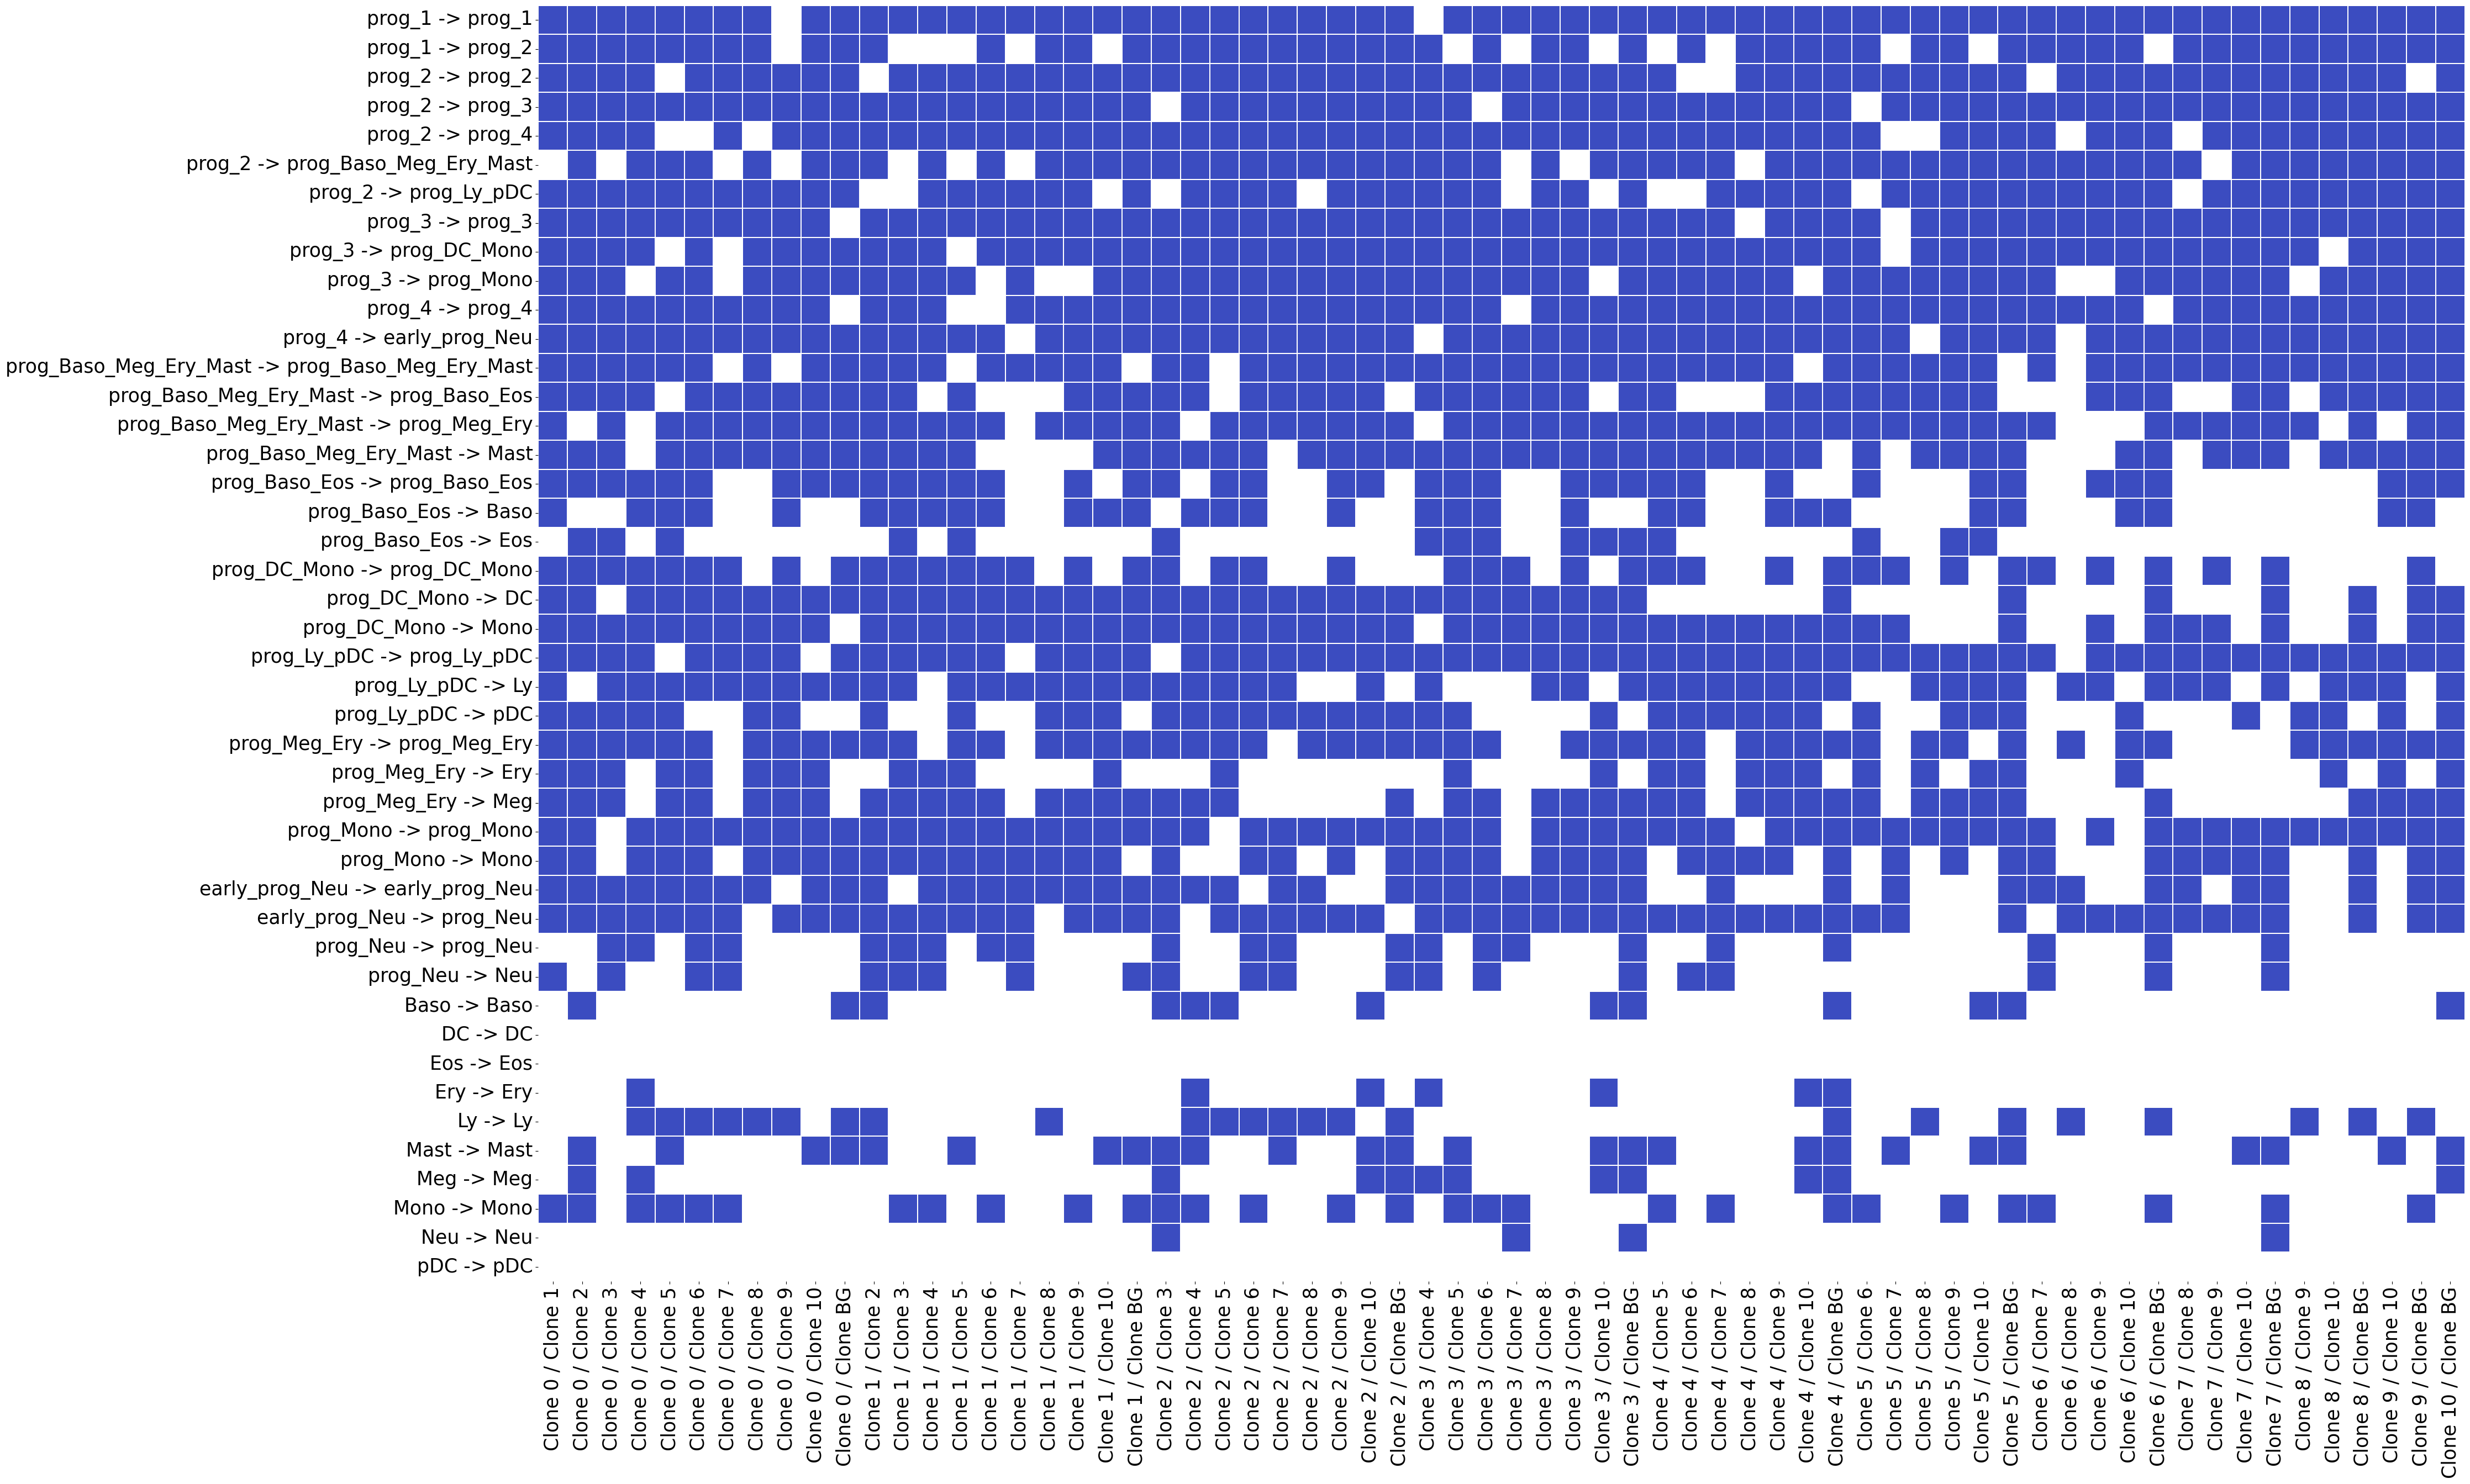

In [32]:
from itertools import product, combinations

combined = [adjusted_p_values, fold_correct]

anno = pd.read_csv(os.path.join(
    model.config['data_loader']['args']['data_dir'], 
    model.config['data_loader']['args']['annots']
))
graph = pd.read_csv(os.path.join(
    model.config['data_loader']['args']['data_dir'], 
    model.config['data_loader']['args']['graphs']
), index_col=0)
np.fill_diagonal(graph.values, 1)
num_clones = model.N.shape[1]

cols = []
for pop1, pop2 in product(range(graph.shape[0]), range(graph.shape[1])):
    if graph.values[pop1][pop2] != 0:
        cols.append('{} -> {}'.format(anno['populations'].values[pop1], anno['populations'].values[pop2]))

index = []
for (c1, c2) in combinations(anno['clones'].values[:num_clones], 2):
    index.append(f'{c1} / {c2}')

combined[0][combined[0] > 0.01] = np.nan
combined[0][np.where(combined[1] < 0.1)] = np.nan
combined = -np.log10(combined[0])
combined[~np.isnan(combined)] = 0

df = pd.DataFrame(data=combined, index=cols, columns=index)
ax = sns.heatmap(df, annot=False, linewidths=.1, cmap='coolwarm', vmin=0, xticklabels=True, yticklabels=True, cbar=False)

plt.xticks(fontsize=25)
plt.yticks(fontsize=25)
plt.grid(False)

fig = ax.get_figure()
fig.set_figwidth(45) 
fig.set_figheight(30) 

plt.savefig('pairwise_comparison_mousehema_day2.svg', bbox_inches='tight', transparent=True, dpi=300)

### Pairwise comparison of all parameters (Mouse Hema) Day 4

In [33]:
from clonaltrans.utils import get_boots_K_total
tpoint = torch.tensor([4.0]).to('cpu')

K_type = model.config['arch']['args']['K_type']
total_K, ref_K = get_boots_K_total(model_list, model, K_type, tpoint)

/ssd/users/mingzegao/.conda/envs/clonetrans/lib/python3.9/site-packages/torchdiffeq/_impl/misc.py:296: UserWarning: t is not on the same device as y0. Coercing to y0.device.
  warnings.warn("t is not on the same device as y0. Coercing to y0.device.")


In [34]:
from clonaltrans.utils import clone_rates_diff_test

p_values, adjusted_p_values, fold_correct = clone_rates_diff_test(model, total_K, correct_method='fdr_bh')
print (p_values.shape, adjusted_p_values.shape, fold_correct.shape)

(66, 22, 22) (44, 66) (44, 66)


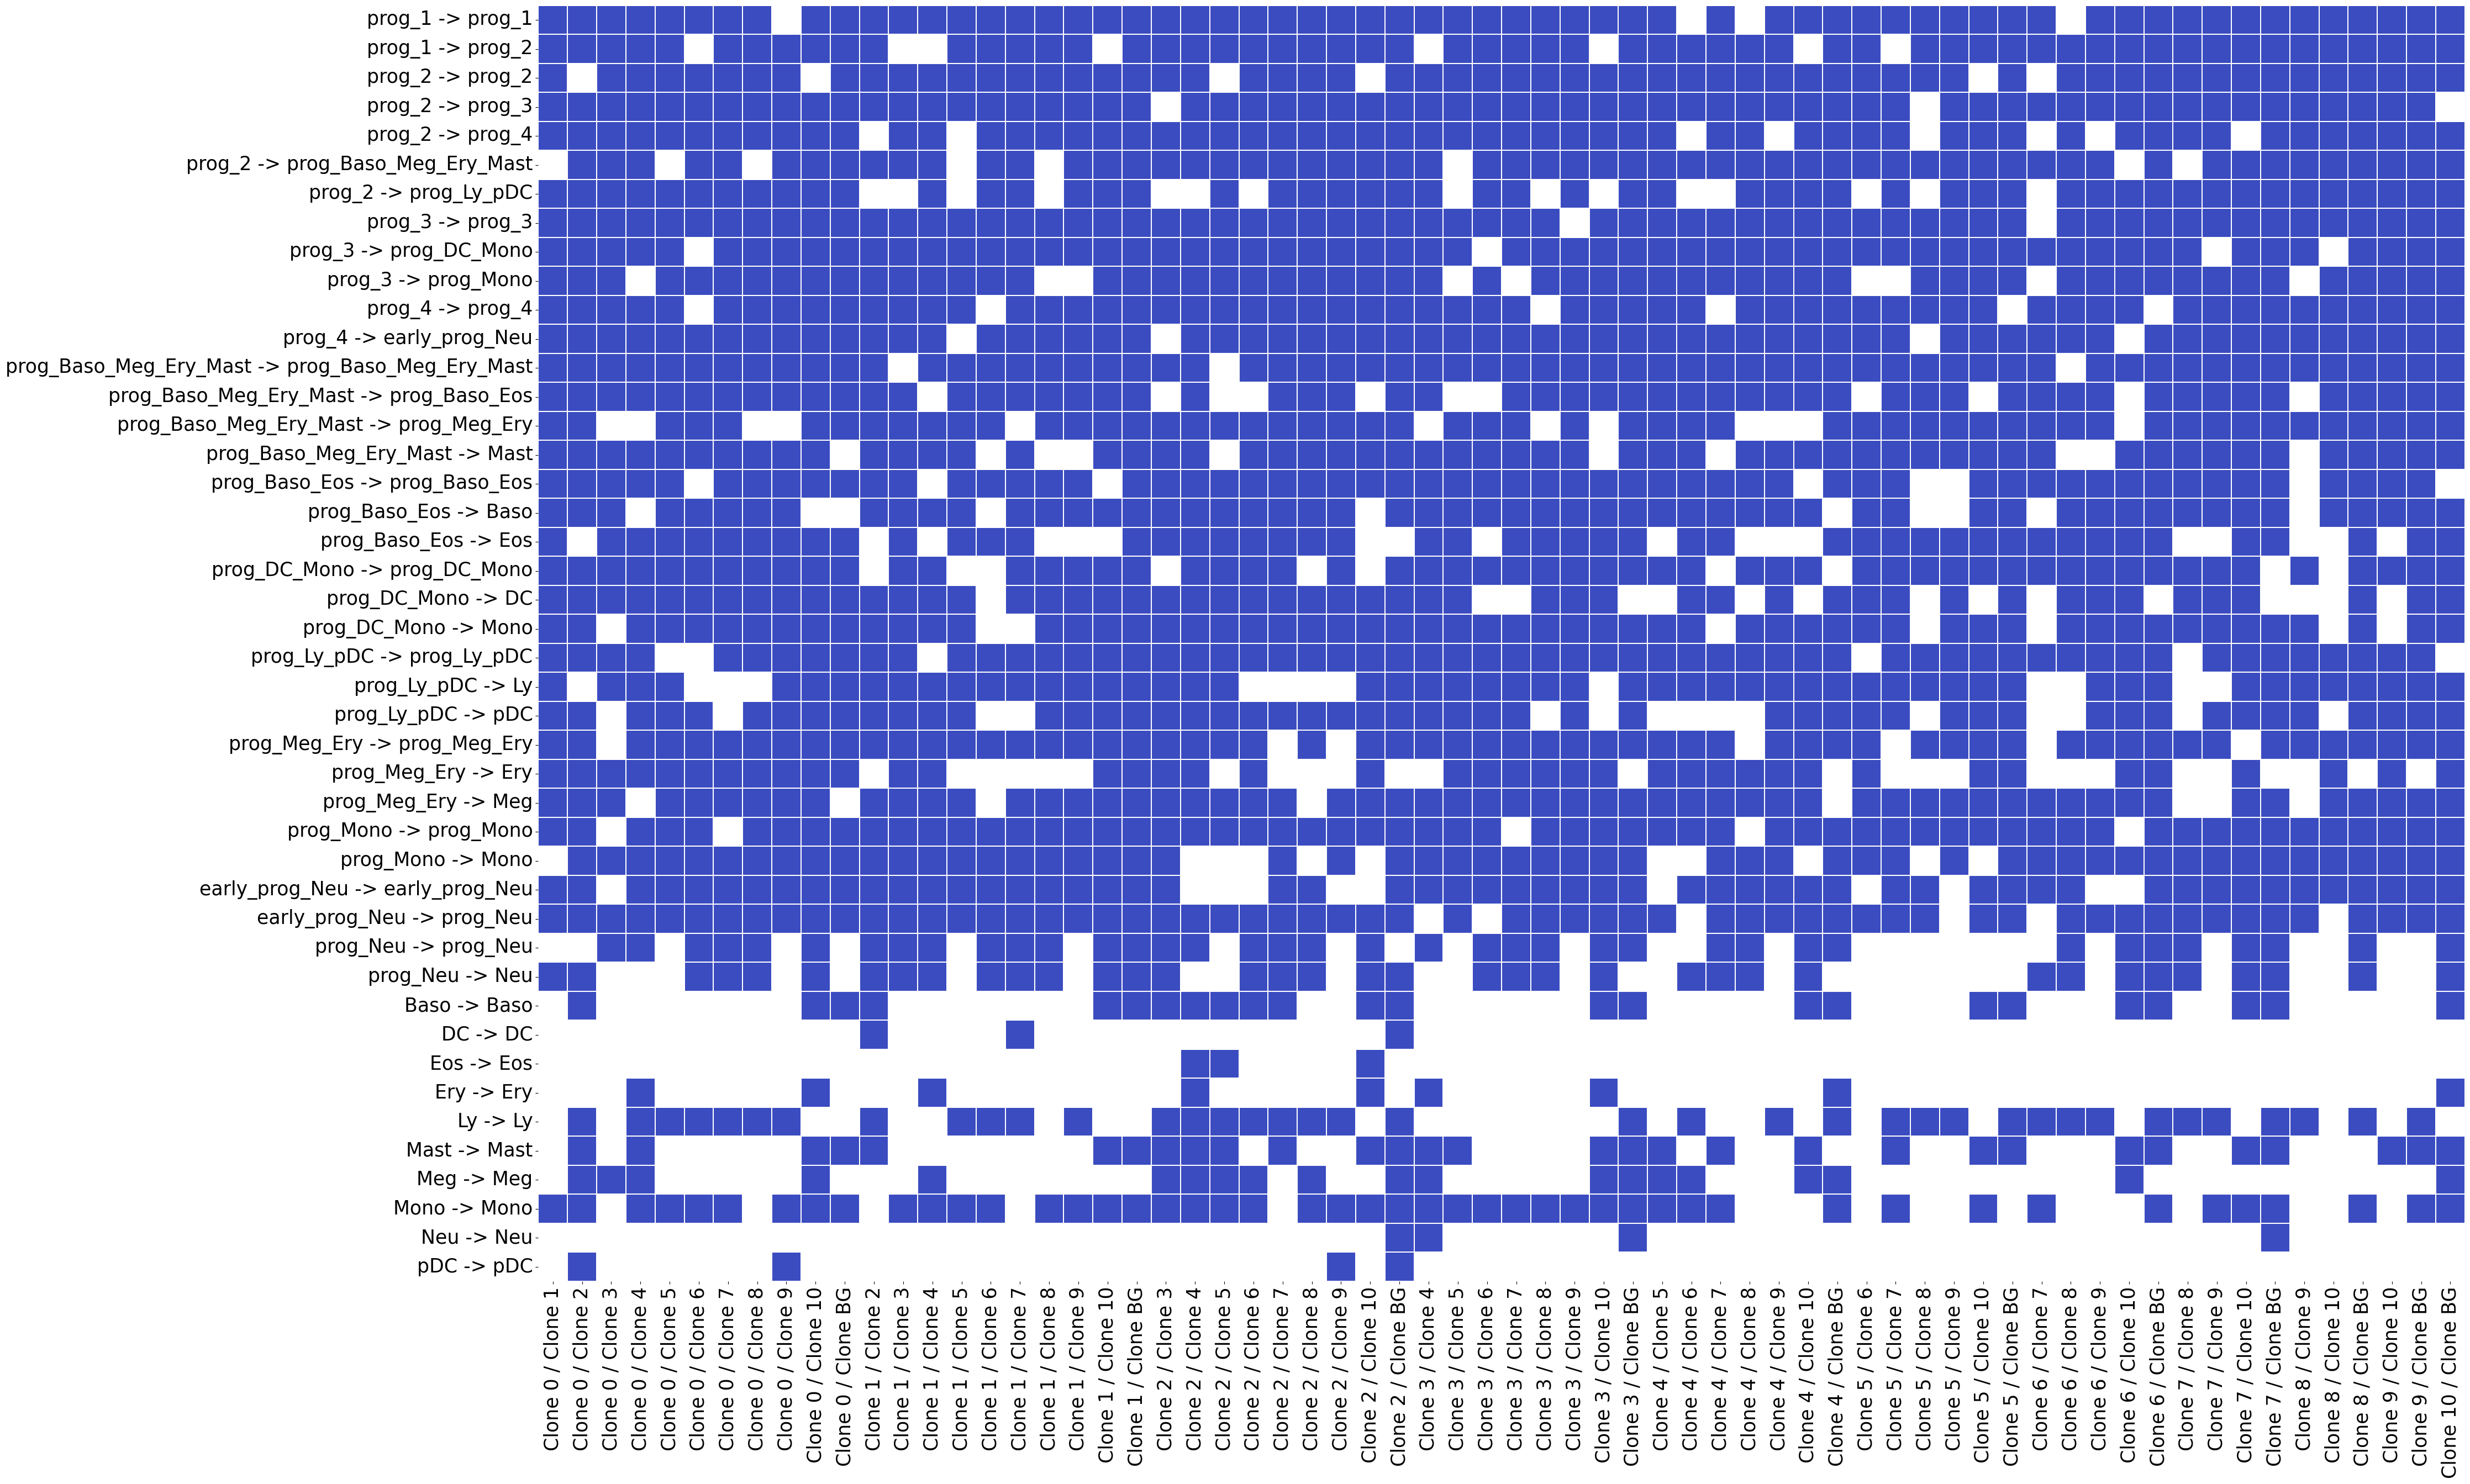

In [35]:
from itertools import product, combinations

combined = [adjusted_p_values, fold_correct]

anno = pd.read_csv(os.path.join(
    model.config['data_loader']['args']['data_dir'], 
    model.config['data_loader']['args']['annots']
))
graph = pd.read_csv(os.path.join(
    model.config['data_loader']['args']['data_dir'], 
    model.config['data_loader']['args']['graphs']
), index_col=0)
np.fill_diagonal(graph.values, 1)
num_clones = model.N.shape[1]

cols = []
for pop1, pop2 in product(range(graph.shape[0]), range(graph.shape[1])):
    if graph.values[pop1][pop2] != 0:
        cols.append('{} -> {}'.format(anno['populations'].values[pop1], anno['populations'].values[pop2]))

index = []
for (c1, c2) in combinations(anno['clones'].values[:num_clones], 2):
    index.append(f'{c1} / {c2}')

combined[0][combined[0] > 0.01] = np.nan
combined[0][np.where(combined[1] < 0.1)] = np.nan
combined = -np.log10(combined[0])
combined[~np.isnan(combined)] = 0

df = pd.DataFrame(data=combined, index=cols, columns=index)
ax = sns.heatmap(df, annot=False, linewidths=.1, cmap='coolwarm', vmin=0, xticklabels=True, yticklabels=True, cbar=False)

plt.xticks(fontsize=25)
plt.yticks(fontsize=25)
plt.grid(False)

fig = ax.get_figure()
fig.set_figwidth(45) 
fig.set_figheight(30) 

plt.savefig('pairwise_comparison_mousehema_day4.svg', bbox_inches='tight', transparent=True, dpi=300)

### Pairwise comparisons of all parameters (Mouse Hema) Day 6

In [36]:
from clonaltrans.utils import get_boots_K_total
tpoint = torch.tensor([6.0]).to('cpu')

K_type = model.config['arch']['args']['K_type']
total_K, ref_K = get_boots_K_total(model_list, model, K_type, tpoint)

/ssd/users/mingzegao/.conda/envs/clonetrans/lib/python3.9/site-packages/torchdiffeq/_impl/misc.py:296: UserWarning: t is not on the same device as y0. Coercing to y0.device.
  warnings.warn("t is not on the same device as y0. Coercing to y0.device.")


In [37]:
from clonaltrans.utils import clone_rates_diff_test

p_values, adjusted_p_values, fold_correct = clone_rates_diff_test(model, total_K, correct_method='fdr_bh')
print (p_values.shape, adjusted_p_values.shape, fold_correct.shape)

(66, 22, 22) (44, 66) (44, 66)


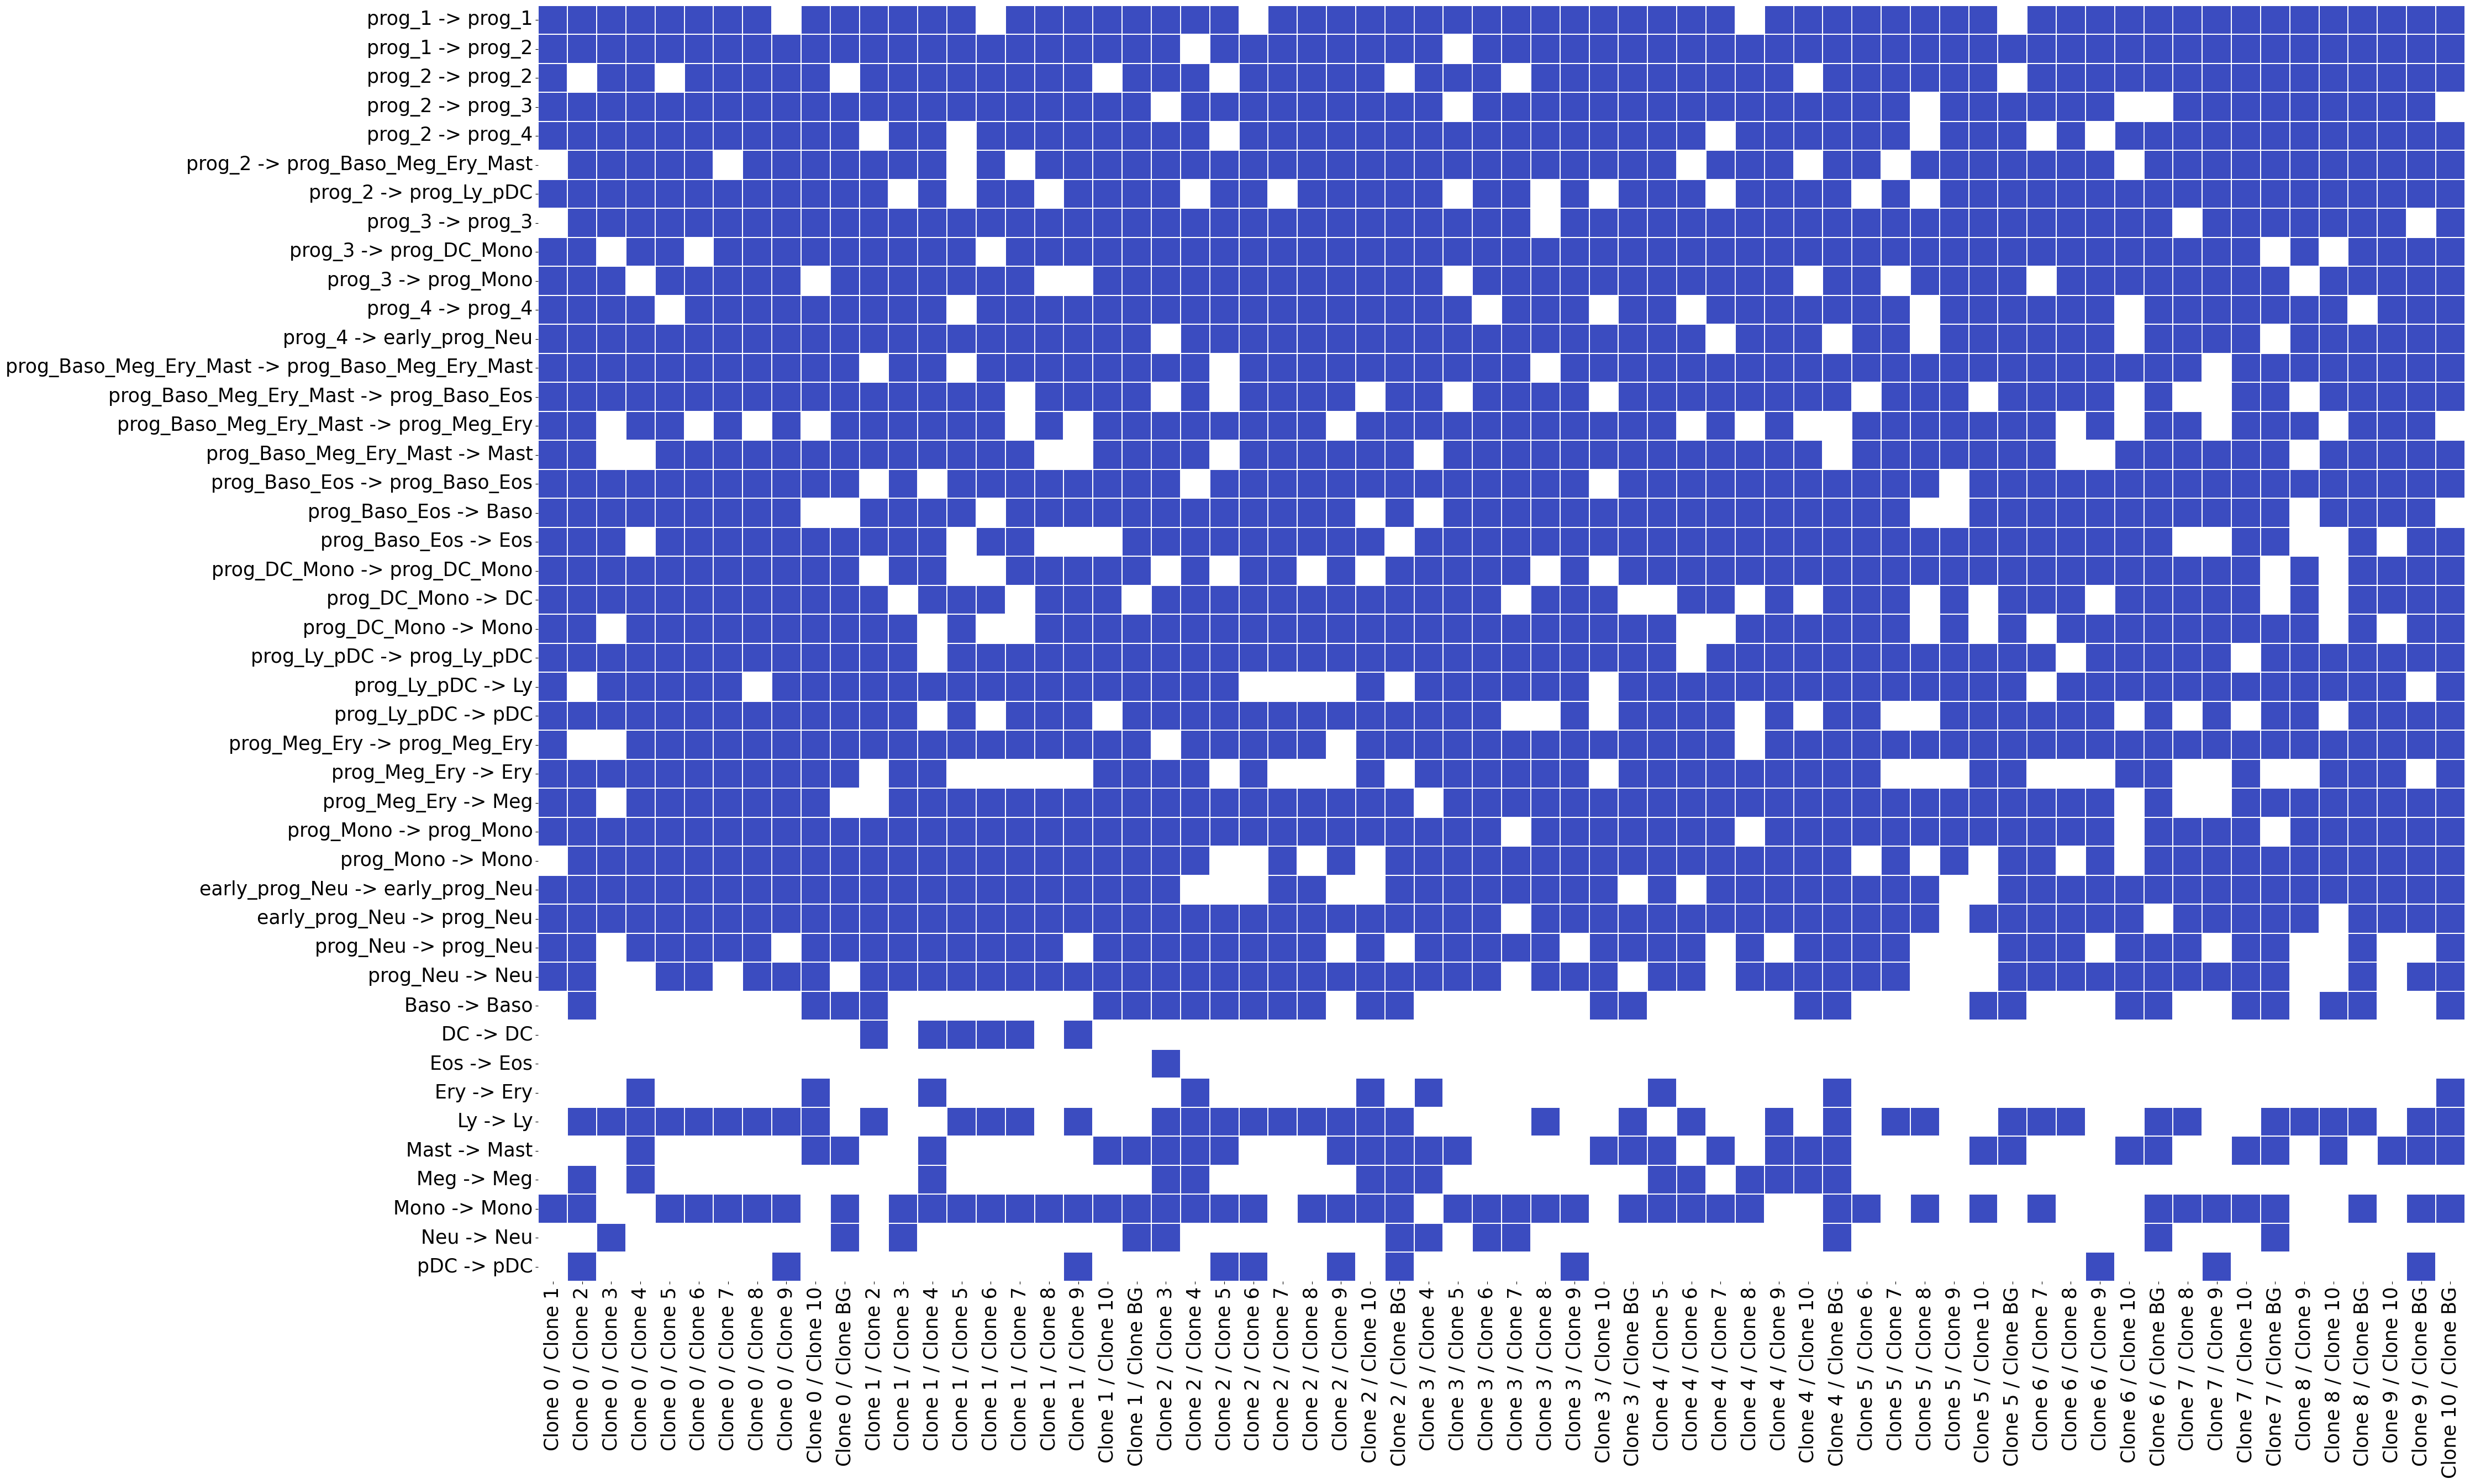

In [39]:
from itertools import product, combinations

combined = [adjusted_p_values, fold_correct]

anno = pd.read_csv(os.path.join(
    model.config['data_loader']['args']['data_dir'], 
    model.config['data_loader']['args']['annots']
))
graph = pd.read_csv(os.path.join(
    model.config['data_loader']['args']['data_dir'], 
    model.config['data_loader']['args']['graphs']
), index_col=0)
np.fill_diagonal(graph.values, 1)
num_clones = model.N.shape[1]

cols = []
for pop1, pop2 in product(range(graph.shape[0]), range(graph.shape[1])):
    if graph.values[pop1][pop2] != 0:
        cols.append('{} -> {}'.format(anno['populations'].values[pop1], anno['populations'].values[pop2]))

index = []
for (c1, c2) in combinations(anno['clones'].values[:num_clones], 2):
    index.append(f'{c1} / {c2}')

combined[0][combined[0] > 0.01] = np.nan
combined[0][np.where(combined[1] < 0.1)] = np.nan
combined = -np.log10(combined[0])
combined[~np.isnan(combined)] = 0

df = pd.DataFrame(data=combined, index=cols, columns=index)
ax = sns.heatmap(df, annot=False, linewidths=.1, cmap='coolwarm', vmin=0, xticklabels=True, yticklabels=True, cbar=False)

plt.xticks(fontsize=25)
plt.yticks(fontsize=25)
plt.grid(False)

fig = ax.get_figure()
fig.set_figwidth(45) 
fig.set_figheight(30) 

plt.savefig('pairwise_comparison_mousehema_day6.svg', bbox_inches='tight', transparent=True, dpi=300)

### Absolute number of divisions (Mouse Hema) prog_2

In [40]:
import os 
os.chdir('/ssd/users/mingzegao/clonaltrans/clonaltrans/')

path = '../trials/v1.2.0/checkpoints/WeinrebDynamicRates/1213_164212/model_last.pt'
model = torch.load(path, map_location='cpu')
device = torch.device('cpu')

import os 
os.chdir('/ssd/users/mingzegao/clonaltrans/')

In [44]:
cluster_names = np.array([
    'prog_1', 'prog_2', 'prog_3', 'prog_4', 
    'prog_Baso_Meg_Ery_Mast',
    'prog_Baso_Eos', 'prog_DC_Mono', 'prog_Ly_pDC', 'prog_Meg_Ery',
    'prog_Mono', 'early_prog_Neu', 'prog_Neu', 'Baso', 'DC', 'Eos',
    'Ery', 'Ly', 'Mast', 'Meg', 'Mono', 'Neu', 'pDC'])

In [41]:
gillespie_dir='./trials/v1.2.0/checkpoints/WeinrebDynamicGillespie/1223_161128/models/'

In [42]:
anno = pd.read_csv(os.path.join(
    model.config['data_loader']['args']['data_dir'], 
    model.config['data_loader']['args']['annots']
))

In [45]:
from clonaltrans.pl import get_div_distribution
import copy

distributions = []

for directory in natsorted(os.listdir(gillespie_dir)):
    if directory.startswith('Clone'):
        gillespie_dir_clones = os.path.join(gillespie_dir, directory)
        
        distribution, counts = get_div_distribution(gillespie_dir_clones, cluster_names, init_celltype=['prog_2'])
        distributions.append(distribution)

In [46]:
for idx, clone in enumerate(distributions):
    distributions[idx] = {key: np.mean(value) if value else np.nan for key, value in clone.items()}

In [48]:
df = pd.DataFrame(distributions, index=anno['clones'].values[:-10]).round(3).T
df

,Clone 0,Clone 1,Clone 2,Clone 3,Clone 4,Clone 5,Clone 6,Clone 7,Clone 8,Clone 9,Clone 10,Clone BG
prog_1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
prog_2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
prog_3,3.514,5.000,0.000,NaN,NaN,4.225,1.850,0.020,6.719,0.646,0.629,6.782
prog_4,3.130,3.135,NaN,0.000,2.849,4.922,1.844,0.045,4.058,1.890,0.495,4.933
prog_Baso_Meg_Ery_Mast,5.920,4.274,0.008,0.000,2.034,3.508,1.712,1.143,2.483,NaN,0.654,4.227
prog_Baso_Eos,9.273,6.889,2.113,NaN,8.310,6.808,2.112,1.000,12.081,NaN,2.401,6.859
prog_DC_Mono,7.038,8.000,4.000,NaN,NaN,7.706,2.210,1.667,NaN,1.915,NaN,9.670
prog_Ly_pDC,0.277,NaN,NaN,0.000,0.227,7.828,NaN,0.017,13.337,0.302,0.786,1.265
prog_Meg_Ery,9.929,21.000,2.585,NaN,4.600,4.370,2.191,NaN,7.298,NaN,5.920,5.625
prog_Mono,6.643,NaN,2.000,NaN,NaN,5.236,1.985,1.111,9.381,3.816,1.946,7.892


In [49]:
df.to_csv('table_of_abs_num_divisions_mousehema_prog2.csv')

### Pairwise comparison of all divisions (Mouse Hema) prog_2

In [54]:
from clonaltrans.pl import get_div_distribution
import copy

distributions = []

for directory in natsorted(os.listdir(gillespie_dir)):
    if directory.startswith('Clone'):
        gillespie_dir_clones = os.path.join(gillespie_dir, directory)
        
        distribution, counts = get_div_distribution(gillespie_dir_clones, cluster_names, init_celltype=['prog_2'])
        distributions.append(distribution)

In [55]:
cluster_names = np.array([
    'prog_1', 'prog_2', 'prog_3', 'prog_4', 
    'prog_Baso_Meg_Ery_Mast',
    'prog_Baso_Eos', 'prog_DC_Mono', 'prog_Ly_pDC', 'prog_Meg_Ery',
    'prog_Mono', 'early_prog_Neu', 'prog_Neu', 'Baso', 'DC', 'Eos',
    'Ery', 'Ly', 'Mast', 'Meg', 'Mono', 'Neu', 'pDC'])

In [58]:
import scipy.stats as stats
p_values = []
checked = []

for cluster in cluster_names:
    p_values.append([])

    for idx, clone_ref in enumerate(anno['clones'].values[:-10]):
        for idy, clone_test in enumerate(anno['clones'].values[:-10]):
            x = distributions[idx][cluster]
            y = distributions[idy][cluster]

            if idx != idy and idy >= idx: 

                if len(x) > 5 and len(y) > 5:
                    _, shapiro_p_c1 = stats.shapiro(x)
                    _, shapiro_p_c2 = stats.shapiro(y)

                    if shapiro_p_c1 > 0.05 and shapiro_p_c2 > 0.05:
                        _, paired_p = stats.ttest_ind(x, y) 
                    else:
                        _, paired_p = stats.mannwhitneyu(x, y)
                    
                    p_values[-1].append(paired_p)
                
                else:
                    p_values[-1].append(np.nan)

p_values = np.array(p_values)

/tmp/ipykernel_1792237/1507075199.py:17: UserWarning: scipy.stats.shapiro: Input data has range zero. The results may not be accurate.
  _, shapiro_p_c2 = stats.shapiro(y)
/tmp/ipykernel_1792237/1507075199.py:16: UserWarning: scipy.stats.shapiro: Input data has range zero. The results may not be accurate.
  _, shapiro_p_c1 = stats.shapiro(x)


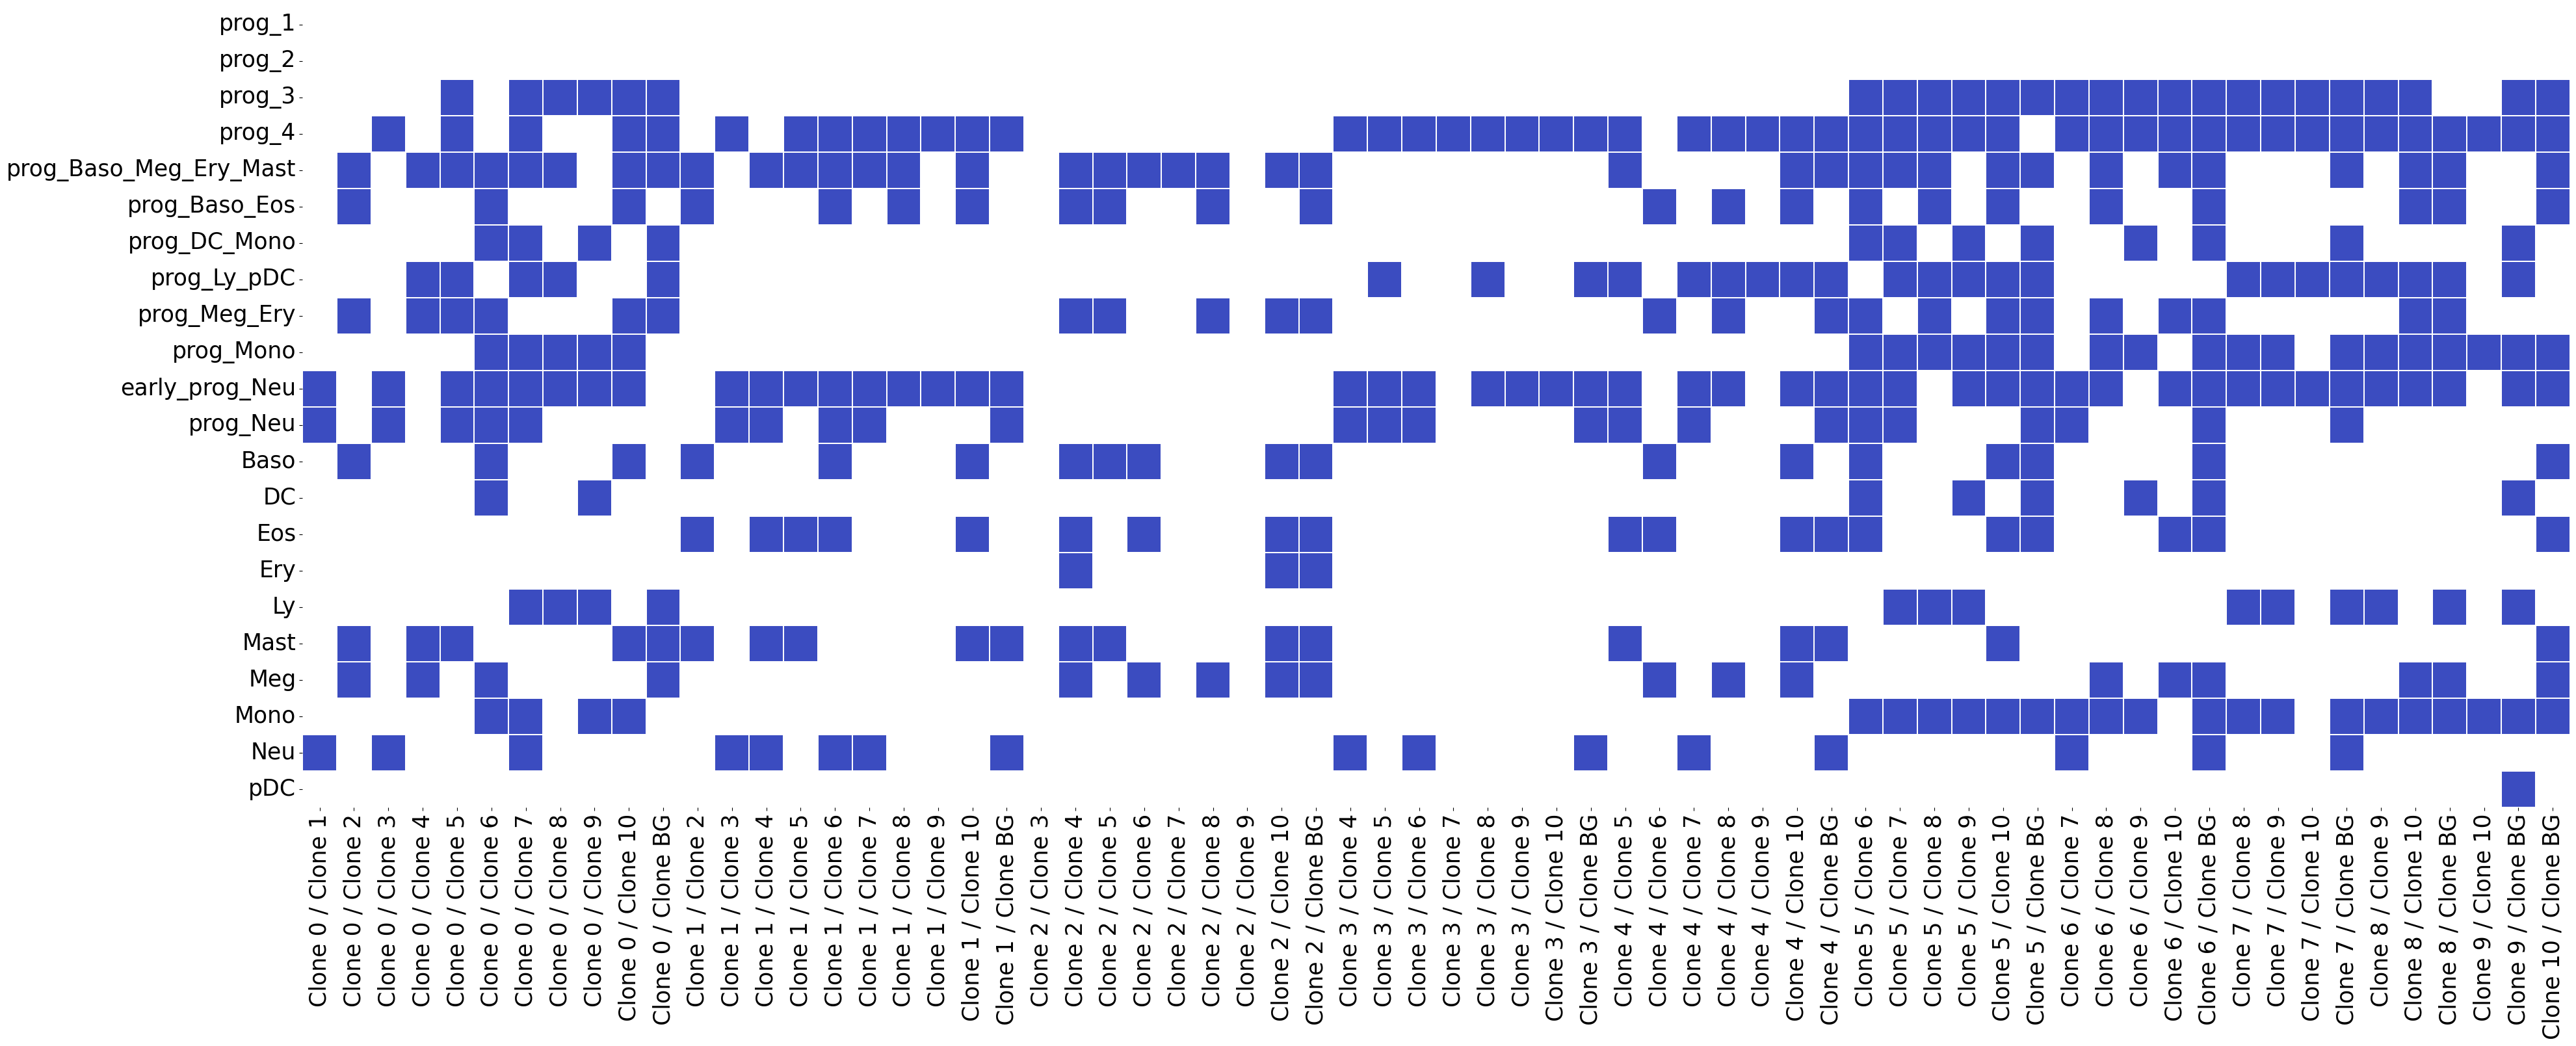

In [62]:
from itertools import product, combinations

combined = p_values

anno = pd.read_csv(os.path.join(
    model.config['data_loader']['args']['data_dir'], 
    model.config['data_loader']['args']['annots']
))

num_clones = model.N.shape[1]

index = []
for (c1, c2) in combinations(anno['clones'].values[:num_clones], 2):
    index.append(f'{c1} / {c2}')

combined[combined > 0.01] = np.nan
combined = -np.log10(combined)
combined[~np.isnan(combined)] = 0

df = pd.DataFrame(data=combined, index=cluster_names, columns=index)
ax = sns.heatmap(df, annot=False, linewidths=.1, cmap='coolwarm', vmin=0, xticklabels=True, yticklabels=True, cbar=False)

plt.xticks(fontsize=25)
plt.yticks(fontsize=25)
plt.grid(False)

fig = ax.get_figure()
fig.set_figwidth(45) 
fig.set_figheight(16) 

plt.savefig('pairwise_divisions_mousehema_prog2.svg', bbox_inches='tight', transparent=True, dpi=300)